I want to see the effects of the new lr scheduling

In [1]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial
import numpy as np


# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss, pinball_loss_tensor, pinball_loss_sum, normalize_batch, compute_mean_std

In [3]:
class thread_net(nn.Module):

    @staticmethod
    def _mlp(sizes: list[int]) -> nn.Sequential:
        """Linear layers with ReLU between; no ReLU after the last linear."""
        if len(sizes) < 2:
            raise ValueError("layer_list needs at least [input_dim, output_dim]")
        layers: list[nn.Module] = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                layers.append(nn.ReLU())
        return nn.Sequential(*layers)

    def __init__(self, layer_list=[12, 40, 40, 40, 1], num_nets=500):
        super().__init__()
        self.layer_list = list(layer_list)
        self.nets = nn.ModuleList(
            [self._mlp(self.layer_list) for _ in range(num_nets)]
        )
        self.num_nets = num_nets

    def forward(self, x):
        outs = [net(x[:, i::self.num_nets]) for i, net in enumerate(self.nets)]
        return torch.cat(outs, dim=1)

In [4]:
all_specs = [
    "sales",
    "7_day_rolling_ema",	
    "30_day_rolling_ema",
    "90_day_rolling_ema",
    "30_day_rolling_min",
    "5_day_lag",
    "6_day_lag",
    "7_day_lag",
    "dif_180_day",
]

In [5]:
# Get data for spec
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    specs=all_specs,
    combine_items=True,
    combine_stores=True
    )

In [6]:
h_cost = 1
l_cost = 3
num_epochs = 500


In [7]:
num_nets = train_loader.dataset.y.shape[1]
in_per_net = train_loader.dataset.x.shape[1] // num_nets
layer_list = [in_per_net, 80, 80, 80, 1]  


First compute with Normalization

In [8]:
net_1 = thread_net(layer_list=layer_list, num_nets=num_nets)

loss = partial(pinball_loss_sum, h_cost=h_cost, l_cost=l_cost)
og_loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
loss_tensor = partial(pinball_loss_tensor, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net_1.parameters(), lr=0.001)

mean, std = compute_mean_std(train_loader, device="cpu")
normalize_func = partial(normalize_batch, mean=mean, std=std)

train_losses, val_losses = train(net_1, optimizer, loss, train_loader, val_loader, epochs=num_epochs, eval_interval=10, device="cpu", use_one_cycle_lr=True, normalize_func=normalize_func)

test_loss = get_test_loss(net_1, test_loader, og_loss, "cpu")

Training: 100%|██████████| 500/500 [02:08<00:00,  3.88step/s, train_loss=43659.3906]                       


In [9]:
# Loss curves for thread_net (split) vs net_2 are plotted in the cell after `net_2` is trained.

In [10]:
test_data = test_loader.dataset.x
test_y = test_loader.dataset.y
test_y_hat = net_1(test_data)
test_loss_tensor_1 = loss_tensor(test_y_hat, test_y)
# Per (store, item) mean pinball over test rows; columns are store-major (store_1_item_1 … store_1_item_50, …)
loss_per_col = test_loss_tensor_1.mean(dim=0).detach().cpu().numpy()
n_stores, n_items = 10, 50


In [11]:
# Mean test pinball loss per target column, greatest to least
ranked = sorted(
    zip(test_loader.dataset.y_columns, loss_per_col),
    key=lambda t: t[1],
    reverse=True,
)
for col, loss_val in ranked:
    print(col, loss_val)


next_store_2_item_28 6733.9653
next_store_2_item_18 6648.8833
next_store_8_item_28 6533.0337
next_store_8_item_15 6518.28
next_store_8_item_13 6479.003
next_store_2_item_15 6473.498
next_store_2_item_25 6275.12
next_store_3_item_28 6162.8984
next_store_8_item_18 6153.129
next_store_2_item_13 6146.6094
next_store_8_item_38 6059.7666
next_store_2_item_38 5732.441
next_store_3_item_15 5681.4917
next_store_8_item_45 5664.6514
next_store_2_item_22 5652.7085
next_store_10_item_15 5627.95
next_store_3_item_18 5555.8257
next_store_2_item_45 5537.072
next_store_10_item_28 5529.9883
next_store_8_item_25 5444.651
next_store_3_item_13 5390.8867
next_store_2_item_36 5383.8564
next_store_8_item_22 5299.5405
next_store_10_item_13 5258.876
next_store_2_item_8 5252.2036
next_store_4_item_28 5216.354
next_store_4_item_15 5194.1626
next_store_9_item_28 5066.6523
next_store_8_item_36 5053.186
next_store_8_item_8 4966.1743
next_store_3_item_38 4953.4844
next_store_9_item_15 4950.2466
next_store_2_item_10 4

Compare with normal lr thread net

In [12]:
net_2 = thread_net(layer_list=layer_list, num_nets=num_nets)
optimizer_1 = torch.optim.Adam(net_2.parameters(), lr=0.001)
train_losses_2, val_losses_2 = train(net_2, optimizer_1, loss, train_loader, val_loader, epochs=num_epochs, eval_interval=10, device="cpu", use_one_cycle_lr=True)
test_loss_2 = get_test_loss(net_2, test_loader, og_loss, "cpu")

Training: 100%|██████████| 500/500 [02:11<00:00,  3.82step/s, train_loss=50088.3164]                      


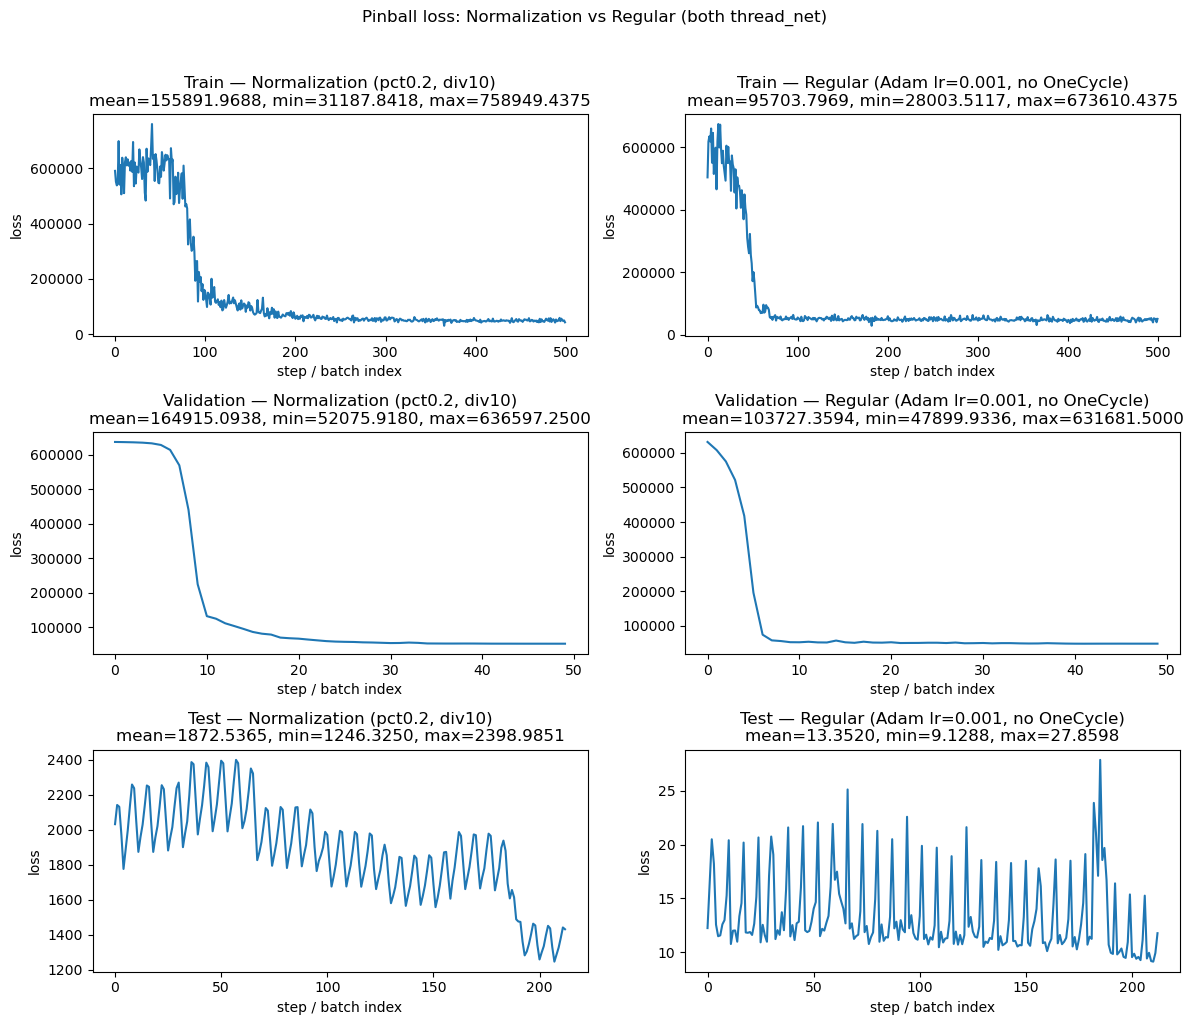

In [13]:
def _stats(a):
    t = torch.tensor(a, dtype=torch.float32)
    return t.mean().item(), t.min().item(), t.max().item()


fig, axs = plt.subplots(3, 2, figsize=(12, 10))

m, lo, hi = _stats(train_losses)
axs[0, 0].plot(train_losses)
axs[0, 0].set_title(f"Train — Normalization (pct0.2, div10)\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")
m, lo, hi = _stats(val_losses)
axs[1, 0].plot(val_losses)
axs[1, 0].set_title(f"Validation — Normalization (pct0.2, div10)\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")
m, lo, hi = _stats(test_loss)
axs[2, 0].plot(test_loss)
axs[2, 0].set_title(f"Test — Normalization (pct0.2, div10)\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")

m, lo, hi = _stats(train_losses_2)
axs[0, 1].plot(train_losses_2)
axs[0, 1].set_title(f"Train — Regular (Adam lr=0.001, no OneCycle)\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")
m, lo, hi = _stats(val_losses_2)
axs[1, 1].plot(val_losses_2)
axs[1, 1].set_title(f"Validation — Regular (Adam lr=0.001, no OneCycle)\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")
m, lo, hi = _stats(test_loss_2)
axs[2, 1].plot(test_loss_2)
axs[2, 1].set_title(f"Test — Regular (Adam lr=0.001, no OneCycle)\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")

for ax in axs.flat:
    ax.set_xlabel("step / batch index")
    ax.set_ylabel("loss")
fig.suptitle("Pinball loss: Normalization vs Regular (both thread_net)", y=1.02)
plt.tight_layout()
plt.show()

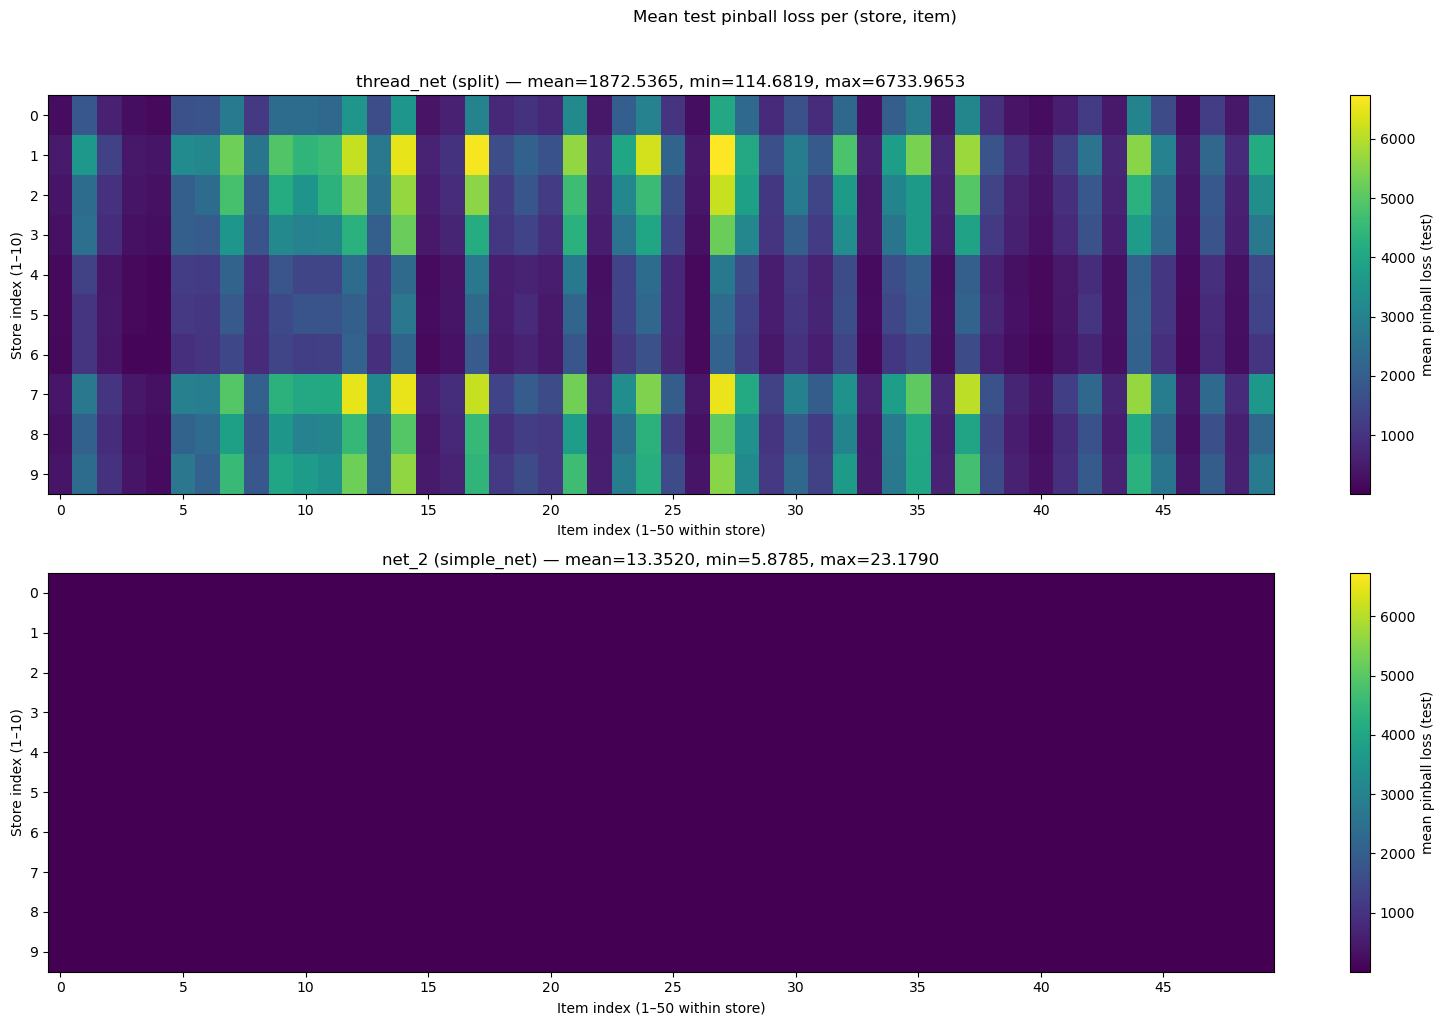

In [14]:
test_y_hat_2 = net_2(test_data)
test_loss_tensor_2 = loss_tensor(test_y_hat_2, test_y)
loss_per_col_2 = test_loss_tensor_2.mean(dim=0).detach().cpu().numpy()

loss_matrix = loss_per_col.reshape(n_stores, n_items)
loss_matrix_2 = loss_per_col_2.reshape(n_stores, n_items)

vmin = float(min(loss_matrix.min(), loss_matrix_2.min()))
vmax = float(max(loss_matrix.max(), loss_matrix_2.max()))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, M, name in (
    (axes[0], loss_matrix, "thread_net (split)"),
    (axes[1], loss_matrix_2, "net_2 (simple_net)"),
):
    im = ax.imshow(M, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xlabel("Item index (1–50 within store)")
    ax.set_ylabel("Store index (1–10)")
    ax.set_title(
        f"{name} — mean={M.mean():.4f}, min={M.min():.4f}, max={M.max():.4f}"
    )
    plt.colorbar(im, ax=ax, label="mean pinball loss (test)")
    ax.set_xticks(np.arange(0, n_items, 5))
    ax.set_yticks(np.arange(n_stores))
plt.suptitle("Mean test pinball loss per (store, item)", y=1.02)
plt.tight_layout()
plt.show()

In [15]:
print(np.sum(loss_matrix > loss_matrix_2))
print(np.mean(loss_matrix - loss_matrix_2))
print(np.sum(loss_matrix < loss_matrix_2))


500
1859.1844
0
